In [21]:
conda install xlrd

Jupyter detected...
2 channel Terms of Service accepted
Channels:
 - defaults
Platform: osx-arm64
doneecting package metadata (repodata.json): - 
doneing environment: - 

# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.


In [22]:

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score, precision_score, confusion_matrix
from imblearn.over_sampling import RandomOverSampler as ROS # training data oversampling
from sklearn.preprocessing import StandardScaler

In [23]:
import pandas as pd

path = './default of credit card clients.xls'
data = pd.read_excel(path)
X_df, y_df = data.iloc[:,1:24], data.iloc[:,24]

X_np = X_df.iloc[1:, :].to_numpy().astype(np.int64)
y_np = y_df.iloc[1:].to_numpy().astype(np.int64)



# **Prétraitement des données et analyse exploratoire**

X1     0
X2     0
X3     0
X4     0
X5     0
X6     0
X7     0
X8     0
X9     0
X10    0
X11    0
X12    0
X13    0
X14    0
X15    0
X16    0
X17    0
X18    0
X19    0
X20    0
X21    0
X22    0
X23    0
Y      0
dtype: int64


/var/folders/sh/s8kx840x6fz1p8_8zwvb7y9r0000gn/T/ipykernel_1291/3551703583.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vars_quanti[col] = pd.to_numeric(vars_quanti[col], errors='coerce')


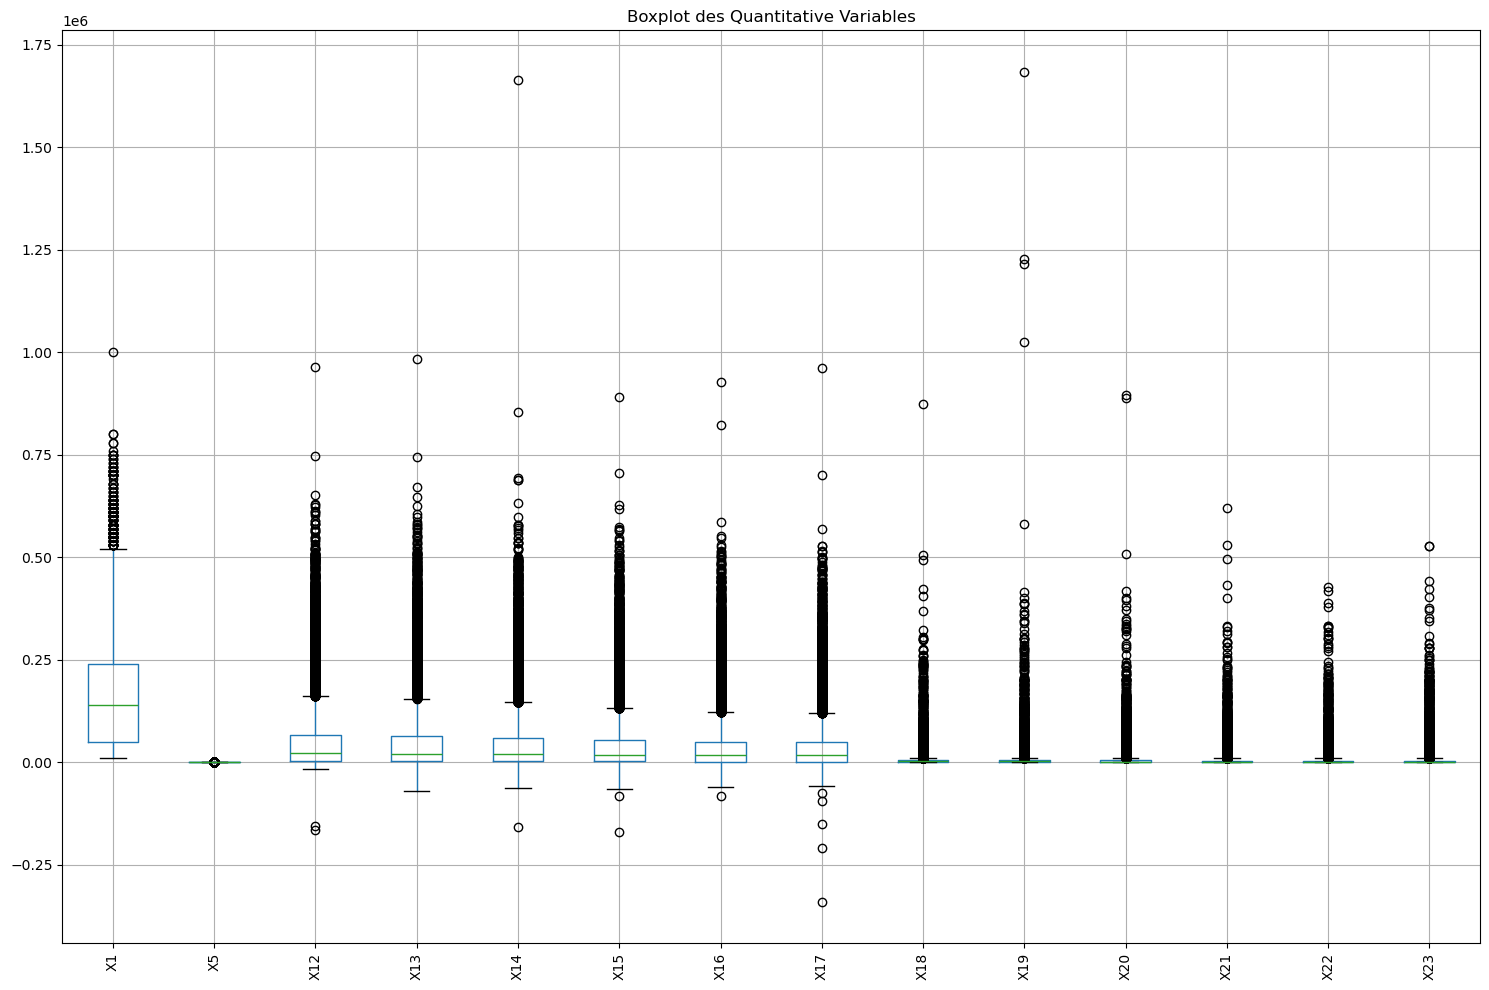

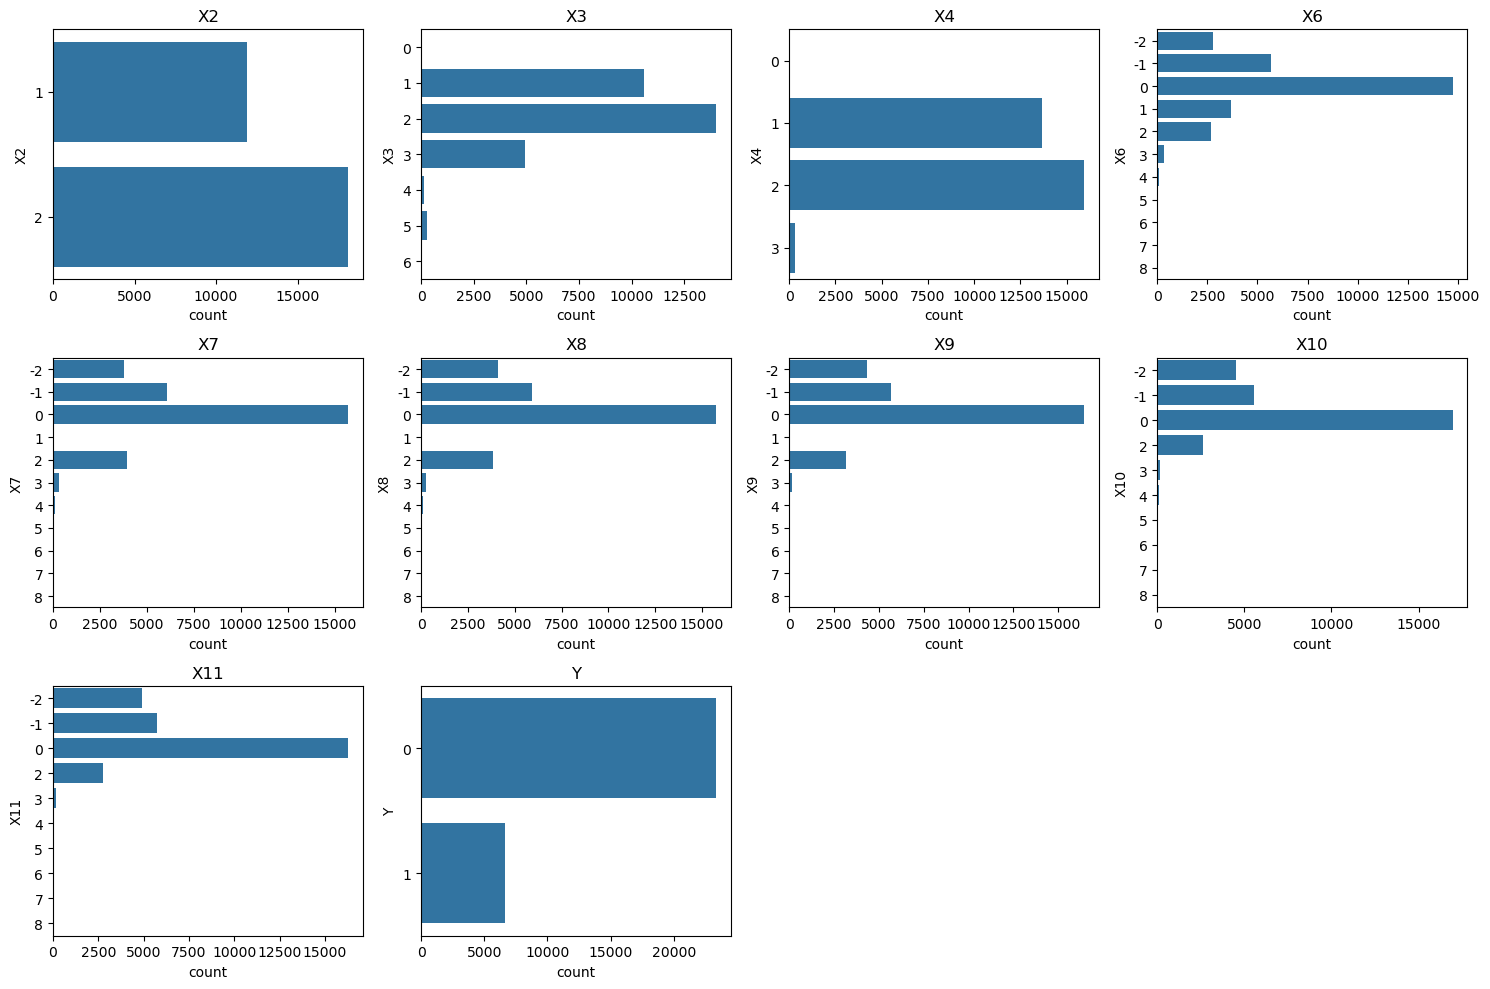

nombre de donnees d'entrainement:  24000
nombre de donnees d'entrainement:  24000
nombre de donnees de test:  6000
nombre de labels de test:  6000
Répartition avant équilibrage : Counter({np.int64(0): 18677, np.int64(1): 5323})
Répartition après équilibrage : Counter({np.int64(0): 18677, np.int64(1): 18677})


In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Nous utilisons la première ligne comme label des variables 
df = data.drop(0, axis=0).drop(data.columns[0], axis=1)

# vérification des valeurs manquantes
print(df.isnull().sum())

# variables quantitatives

vars_quanti = df[['X1', 'X5', 'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18', 'X19', 'X20', 'X21', 'X22', 'X23']]

for col in vars_quanti.columns:
    vars_quanti[col] = pd.to_numeric(vars_quanti[col], errors='coerce')

# variables qualitatives
vars_quali = df[['X2','X3','X4','X6','X7','X8','X9','X10','X11','Y']]
vars_quali = vars_quali.astype('category')

# boxplot des variables quantitatives
plt.figure(figsize=(15, 10))  # Adjust figure size as needed
vars_quanti.boxplot()
plt.xticks(rotation=90) 
plt.title('Boxplot des Quantitative Variables')
plt.tight_layout()  
plt.show()

# histogramme des variables qualitatives
plt.figure(figsize=(15, 10))
for i, col in enumerate(vars_quali.columns):
    plt.subplot(3, 4, i+1)  
    sns.countplot(y=vars_quali[col])
    plt.title(f'{col}')
    plt.tight_layout()
plt.show()


#split en données d'entrainement et de test
from sklearn.model_selection import train_test_split

X_np_train, X_np_test, y_np_train, y_np_test = train_test_split(
    X_np, y_np , test_size=0.2, random_state=42, shuffle=True)

print("nombre de donnees d'entrainement: ", len(X_np_train))
print("nombre de donnees d'entrainement: ", len(y_np_train))
print("nombre de donnees de test: ", len(X_np_test))
print("nombre de labels de test: ", len(y_np_test))


# Standardisation des variables quantitatives et encodage des variables qualitatives
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder

num_indices = [0, 4, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22]  # Indices de X1, X5, X12-X23
cat_indices = [1, 2, 3, 5, 6, 7, 8, 9, 10]  # Indices de X2, X3, X4, X6-X11

preprocessor = ColumnTransformer([
    ('num', MinMaxScaler(), num_indices),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_indices)
])


# Equilibrage des classes Y=0 et Y=1 pour un meilleur entrainement
from imblearn.over_sampling import RandomOverSampler
from collections import Counter
import pandas as pd

## Initialisation du RandomOverSampler
ros = RandomOverSampler(random_state=42)

## Application de l'oversampling
X_resampled, y_resampled = ros.fit_resample(X_np_train, y_np_train)

print("Répartition avant équilibrage :", Counter(y_np_train))
print("Répartition après équilibrage :", Counter(y_resampled))

# Fit du preprocessor sur les données rééchantillonnées seulement 
X_resampled = preprocessor.fit_transform(X_resampled)

# Application sur le test (sans fit, pour éviter la fuite de données)
X_test = preprocessor.transform(X_np_test)




# **K Plus Proches Voisins (KPPV)**

              precision    recall  f1-score   support

           0     0.8686    0.6702    0.7566      4687
           1     0.3515    0.6382    0.4533      1313

    accuracy                         0.6632      6000
   macro avg     0.6101    0.6542    0.6050      6000
weighted avg     0.7555    0.6632    0.6902      6000



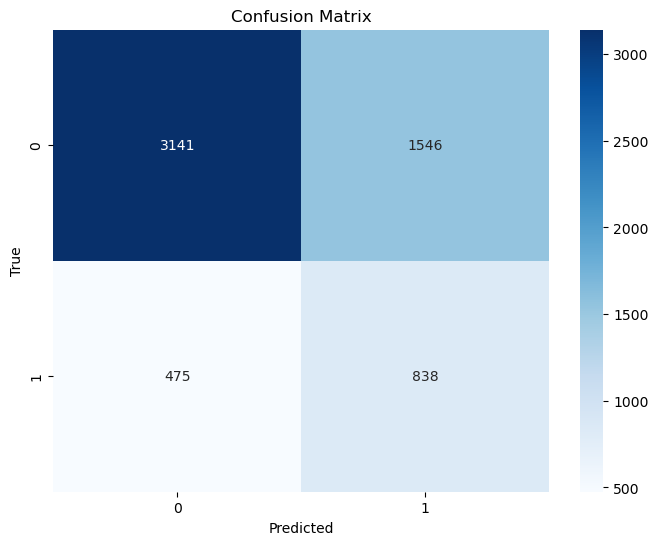

In [25]:
from sklearn.metrics import classification_report  
from sklearn.neighbors import KNeighborsClassifier  

clf = KNeighborsClassifier(n_neighbors=7) # 

clf.fit(X_resampled, y_resampled) # 

y_pred = clf.predict(X_test) #

print(classification_report(y_np_test, y_pred, digits= 4)) #

# matrice de confusion
cm = confusion_matrix(y_np_test, y_pred)

# visualisation de la matrice de confusion
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=clf.classes_, 
            yticklabels=clf.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# **Arbres de décision**

              precision    recall  f1-score   support

           0  0.82550625 0.81758054 0.82152428      4687
           1  0.37039764 0.38309216 0.37663796      1313

    accuracy                      0.72250000      6000
   macro avg  0.59795195 0.60033635 0.59908112      6000
weighted avg  0.72591331 0.72250000 0.72416832      6000



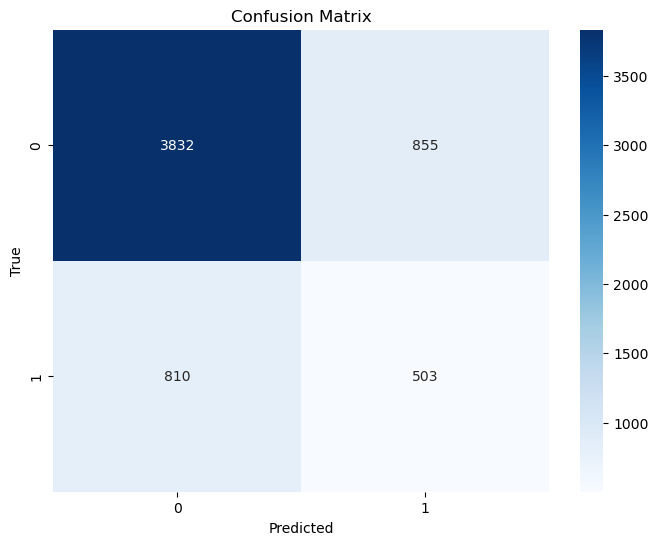

In [26]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Construction d'un arbre de décision de profondeur maximale 8
dt = DecisionTreeClassifier()
dt.fit(X_resampled, y_resampled)

y_pred = dt.predict(X_test)

print(classification_report(y_np_test, y_pred, digits= 8))

# matrice de confusion
cm = confusion_matrix(y_np_test, y_pred)

# visualisation de la matrice de confusion
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=clf.classes_, 
            yticklabels=clf.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()



# **Classificateur de Bayes**

              precision    recall  f1-score   support

           0     0.8241    0.9569    0.8856      4687
           1     0.6380    0.2711    0.3805      1313

    accuracy                         0.8068      6000
   macro avg     0.7311    0.6140    0.6331      6000
weighted avg     0.7834    0.8068    0.7751      6000

Précisions des 5 plis :  [0.36541667 0.37208333 0.38583333 0.37604167 0.37729167]
Précision moyenne :  0.3753333333333333


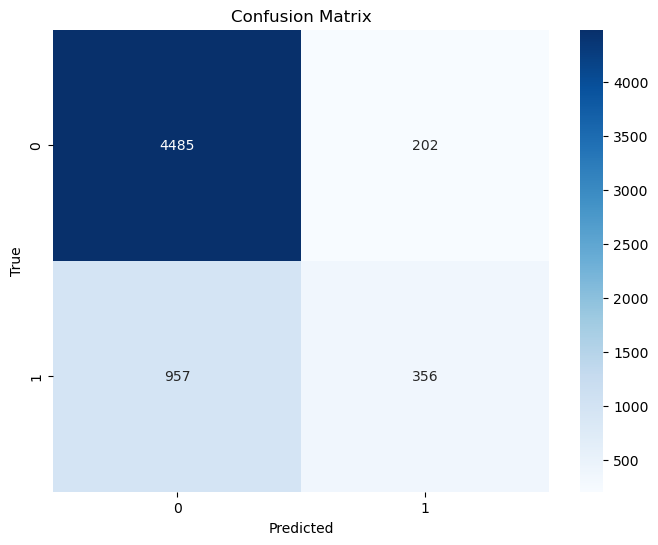

In [27]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import StratifiedKFold, cross_val_score  
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Convert sparse matrices to dense arrays if needed
if hasattr(X_resampled, 'toarray'):
    X_resampled = X_resampled.toarray()
if hasattr(X_test, 'toarray'):
    X_test = X_test.toarray()
if hasattr(X_np_train, 'toarray'):
    X_np_train = X_np_train.toarray()

nb = GaussianNB()

nb.fit(X_resampled, y_resampled)

y_pred = nb.predict(X_test)

print(classification_report(y_np_test, y_pred, digits=4))

k_folds = StratifiedKFold(n_splits=5)
NB_Cross_Val = cross_val_score(nb, X_np_train, y_np_train, cv=k_folds)

print('Précisions des 5 plis : ', NB_Cross_Val)

print('Précision moyenne : ', NB_Cross_Val.mean())

# matrice de confusion
cm = confusion_matrix(y_np_test, y_pred)

# visualisation de la matrice de confusion
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=nb.classes_,  # Changed from clf.classes_ to nb.classes_
            yticklabels=nb.classes_)  # Changed from clf.classes_ to nb.classes_
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# **SVM**

              precision    recall  f1-score   support

           0     0.8775    0.8250    0.8505      4687
           1     0.4852    0.5887    0.5320      1313

    accuracy                         0.7733      6000
   macro avg     0.6814    0.7069    0.6912      6000
weighted avg     0.7916    0.7733    0.7808      6000



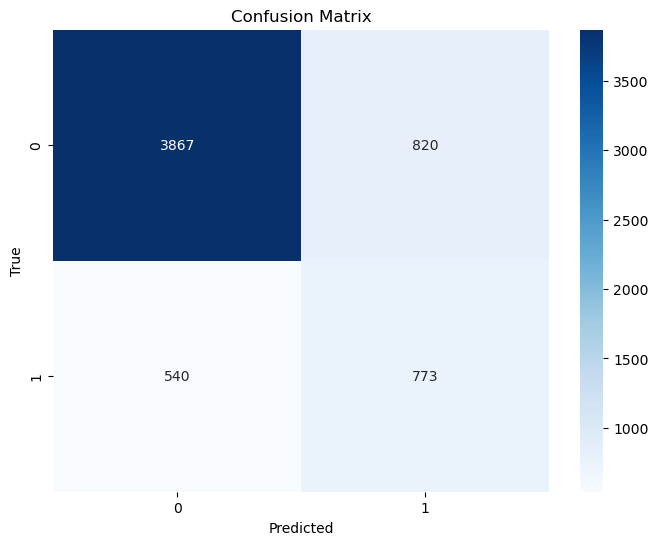

In [28]:
from sklearn.svm import SVC

model = SVC()
model.fit(X_resampled, y_resampled)
y_pred = model.predict(X_test)

print(classification_report(y_np_test, y_pred, digits=4))

# matrice de confusion
cm = confusion_matrix(y_np_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=clf.classes_, 
            yticklabels=clf.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


# **Réseau de neurones à deux couches cachées**

              precision    recall  f1-score   support

           0     0.8773    0.7886    0.8306      4687
           1     0.4454    0.6062    0.5135      1313

    accuracy                         0.7487      6000
   macro avg     0.6614    0.6974    0.6721      6000
weighted avg     0.7828    0.7487    0.7612      6000



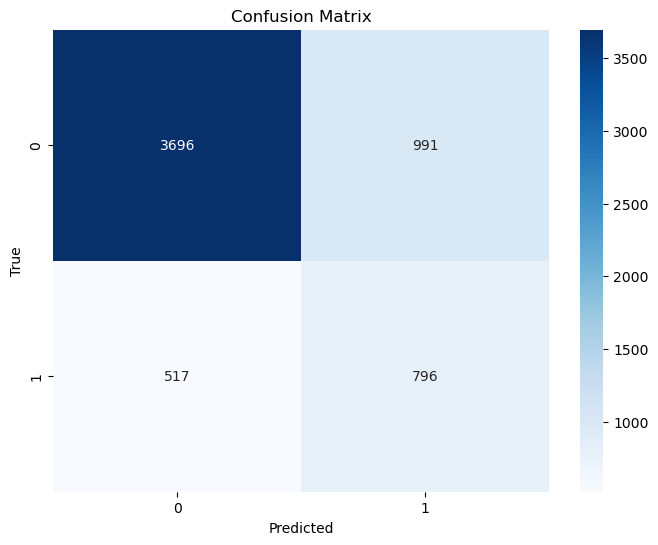

In [29]:
from sklearn.neural_network import MLPClassifier
from sklearn.datasets import make_moons

# Réseau de neurones : 2 couches cachées de 5 neurones (ReLU)
mlp = MLPClassifier(hidden_layer_sizes=(5,2), activation='relu',
                    max_iter=1000, random_state=42)

# Apprentissage
mlp.fit(X_resampled, y_resampled)

# Prédiction sur le test
y_pred = mlp.predict(X_test)

# Évaluation
print(classification_report(y_np_test, y_pred, digits=4))

# matrice de confusion
cm = confusion_matrix(y_np_test, y_pred)


plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=clf.classes_, 
            yticklabels=clf.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


# **Forêt aléatoire**

              precision    recall  f1-score   support

           0     0.8499    0.9179    0.8826      4687
           1     0.5896    0.4212    0.4913      1313

    accuracy                         0.8092      6000
   macro avg     0.7197    0.6695    0.6869      6000
weighted avg     0.7929    0.8092    0.7969      6000



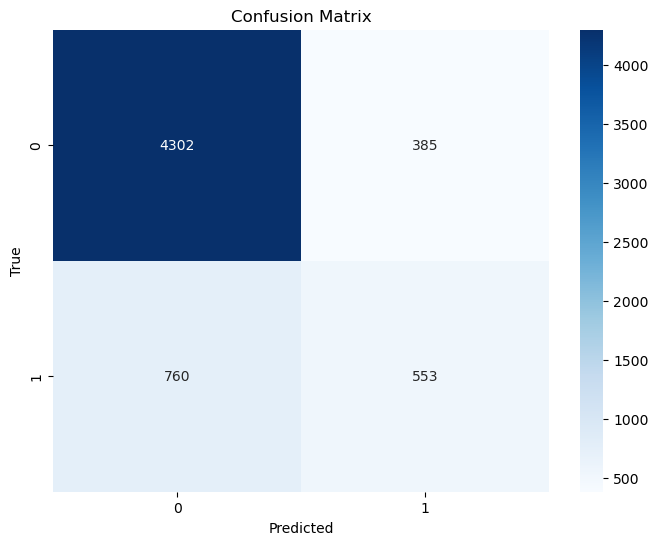

In [30]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=50)
rf.fit(X_resampled, y_resampled)
y_pred = rf.predict(X_test)

print(classification_report(y_np_test, y_pred, digits= 4))

# matrice de confusion
cm = confusion_matrix(y_np_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=clf.classes_, 
            yticklabels=clf.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

